In [1]:
%load_ext autoreload
%autoreload 2
%load_ext line_profiler

# load general packages
import numpy as np
import matplotlib.pyplot as plt
import time

# load modules related to this exercise
from model_zurcher import zurcher
from solve_NFXP import solve_NFXP
import estimate_NFXP as estimate

#### Before solving the exercise, you should download line_profiler. Line_profiler is a tool to check the performance of our code. To install line_profiler, you can open anaconda prompt and write "pip install line-profiler" (without the " " of course). If you want to know more about line_profiler, check the link below:

https://github.com/rkern/line_profiler.

# Exercise 1

#### Consider the engine replacement model given by:

$$
V(x,\epsilon) = \max_{d\in \{0,1\}} \big\{ u(x,d) + \epsilon(d) + \beta
\underbrace{\int_{X} \int_{\Omega} V(x',\epsilon') p(x'|x,d) q(\epsilon'|x') dx' d\epsilon' }_{EV(x,d)} \big\}
$$

Where $ \varepsilon $ is extreme value Type I distribued and utility is given by:

$$
u(x,d)=\left \{
\begin{array}{ll}
    -RC-c(0,\theta_1) & \text{if }d=\text{replace}=1 \\
    -c(x,\theta_1) & \text{if }d=\text{keep}=0
\end{array} \right.
$$

Here

- $ RC $ = replacement cost  
- $ c(x,\theta_1) $ = cost of maintenance with preference parameters $ \theta_1 $  

And in integrated value function form:
$$\bar{V}(x)=\int_{\Omega} \left[ \max_{d\in \{0,1 \}} \{ u(x,d)+\epsilon(d)+\beta \int_{X} \bar{V}(x')p(x'\vert x,d) dx'  \} \right] d\epsilon$$


### 1. Look at ReadMe.txt to get an overview of the code

### 2. Investigate how the code works: ensure you understand:
<il type ="a">
<li> zurcher.init</li>
<li> zurcher.setup</li>
<li> zurcher.create_grid</li>
<li> zucher.state_transition </li>
<li> zucher.bellman </li>

You can see how they are called below
    

### 3. Run the code below and make sure you understand what we are printing. 
What does the last transition probability in each (non-truncated) row (equal to 0.05 here) come from?

**Answer.** The supplied probabilities sum to $0.65+0.20+0.10=0.95$. The code assigns the residual probability, $1-0.95=0.05$, to the final mileage increment so each transition row sums to one.

In [2]:
do_settings = { 'RC': 0.5, 'n': 12, 'p':[0.65,0.2,0.1] }

model = zurcher(**do_settings)

print(f'Milage grid:\n{model.grid}\n')
print(f'Transition probabilities conditional on not replacing, d=0:\n{model.P1}\n')
print(f'Transition probabilities conditional on replacing, d=1:\n{model.P2}\n')

Vbar = model.bellman(np.zeros((model.n)),output=1)
print(f'Bellman one iteration of VFI:\n{Vbar}',)

Milage grid:
[ 0  1  2  3  4  5  6  7  8  9 10 11]

Transition probabilities conditional on not replacing, d=0:
[[0.65 0.2  0.1  0.05 0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.65 0.2  0.1  0.05 0.   0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.65 0.2  0.1  0.05 0.   0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.65 0.2  0.1  0.05 0.   0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.65 0.2  0.1  0.05 0.   0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.65 0.2  0.1  0.05 0.   0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.65 0.2  0.1  0.05 0.   0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.65 0.2  0.1  0.05 0.  ]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.65 0.2  0.1  0.05]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.65 0.2  0.15]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.65 0.35]
 [0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   0.   1.  ]]

Transition probabilities conditional on replacing, d=1:
[[0.65 0.2  0.1  0.05 0.   0.   0.   0.   0.   0.   0.   0.  ]
 [0.65 0.2 

#### Newton's Method

Next, we need to solve the model. Rust 1987 uses Newton–Kantorovich (NK) theorem to solve the Bellman equation in the engine replacement model. To understand the NK algorithm, consider using the Newton's method to solve the single-variable equation, $f(x)=0$. The Newton method uses the iterative procedure stated below to solve the equation:

$$x_{n+1} = x_{n} - \frac{f(x_n)}{f'(x_n)}$$

### 4. Use the Newton's Method to solve the equation below. Fill in the Newton step. Try to change the starting value and see if the solution changes.


$$f(x) = 3x^2 - \exp(x)=0$$

$$f'(x) = g(x) = 6x-\exp(x) $$

**Answer.** Newton's method is local. This equation has three roots (approximately $-0.46$, $0.91$, and $3.73$), so changing the starting value can lead to a different root and a poor starting value can also fail to converge. Starting from $x_0=5$ gives the root near $3.73$.

Root of f(x): 3.73
Number of iterations to achieve convergence: 6


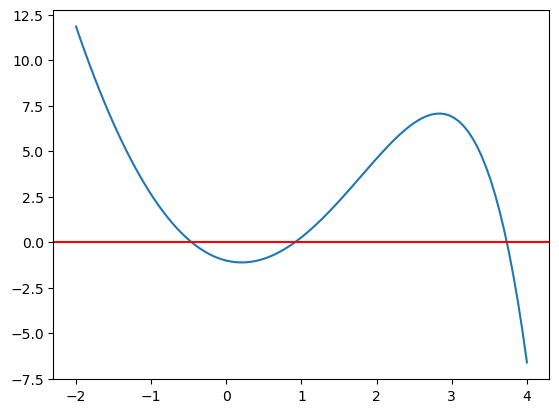

In [3]:
f = lambda x: 3*x**2-np.exp(x)
g = lambda x: 6*x-np.exp(x)

def newton(f, g, x0, tol=10e-5, max_iter=100):

    # initialize
    delta = 2000
    i = 0

    # iterate
    while (i<=max_iter and delta>tol):
        x1 = x0 - f(x0)/g(x0)

        delta = abs(x1-x0)

        i += 1
        x0 = x1

    return x1, i


x0,it = newton(f = f, g = g, x0 = 5)

x = np.linspace(-2, 4, num=100)
fx = f(x)
plt.plot(x, fx)
plt.axhline(y=0, color='r', linestyle='-')

print('Root of f(x):', round(x0,2))
print('Number of iterations to achieve convergence:', it)

#### Newton-Kantorovich

Now consider solving the engine replacement model. To do so, we need to find the integrated value function that solves the Bellman equation.

$$
\bar{V}(x) =  \bar{\Gamma}(\bar{V})(x) \quad\Leftrightarrow\quad (I - \bar{\Gamma})(\bar{V})(x)=\mathbb{0}
$$

Similar to the Newton iteration, the **NK iteration** uses the following equation

$$
\bar{V}_{k+1} = \bar{V}_{k} - (I-\bar{\Gamma}')^{-1} (I-\bar{\Gamma})(EV_k)
$$

- The new operator $(I - \bar{\Gamma})(\bar{V})$ is the difference between the identity operator $I$ and Bellman operator $ \Gamma  $  
- $ \mathbb{0} $ is "zero function" 
- $ I-\Gamma' $ is a Fréchet derivative of the operator $ I-\Gamma $  

### 5. Solve the model. In order to solve the model, you should understand:
<li> solve_NFXP.init</li>
<li> solve_NFXP.setup</li>
<li> solve_NFXP.poly </li>
<li> solve_NFXP.sa </li>
<li> solve_NFXP.nk </li>
</il>

You can see how they are called below: 

In [4]:
algorithm = 'poly'
do_settings_solver = {

    'sa_min': 10,
    'sa_max': 1000000,  
    'printfxp': 2
}

solver = solve_NFXP(**do_settings_solver)
model = zurcher()

In [5]:
Vbar0 = np.zeros((model.n)) # Initial guess
if algorithm == 'sa':
    Vbar = solver.sa(model.bellman, Vbar0)

elif algorithm == 'poly':
    Vbar = solver.poly(model.bellman, Vbar0, beta = model.beta)

else:
    print('Algorithm must be "sa" or "poly"')


Beginning SA-iterations (for the 1 time)

Iteration 1	tol: 0.4273	tol(j)/tol(j-1): nan
Iteration 2	tol: 0.4272	tol(j)/tol(j-1): nan
Iteration 3	tol: 0.4272	tol(j)/tol(j-1): nan
Iteration 4	tol: 0.4271	tol(j)/tol(j-1): nan
Iteration 5	tol: 0.4271	tol(j)/tol(j-1): nan
Iteration 6	tol: 0.4270	tol(j)/tol(j-1): nan
Iteration 7	tol: 0.4269	tol(j)/tol(j-1): nan
Iteration 8	tol: 0.4268	tol(j)/tol(j-1): nan
Iteration 9	tol: 0.4266	tol(j)/tol(j-1): nan
Iteration 10	tol: 0.4264	tol(j)/tol(j-1): nan
Iteration 11	tol: 0.4262	tol(j)/tol(j-1): 0.9994

SA stopped prematurely due to relative tolerance. Start NK iterations

Elapsed time 0.0022 seconds

Beginning NK-iterations (for the 1 time)

Iteration 1	tol: 13.1676	tol(j)/tol(j-1): 1.0000
Iteration 2	tol: 0.3080	tol(j)/tol(j-1): 0.0234
Iteration 3	tol: 0.0896	tol(j)/tol(j-1): 0.2907
Iteration 4	tol: 0.0033	tol(j)/tol(j-1): 0.0369
Iteration 5	tol: 0.0000	tol(j)/tol(j-1): 0.0035
Iteration 6	tol: 0.0000	tol(j)/tol(j-1): 0.0000

NK converged after 6 ite

#### 6. Now we have to estimate the model. In order to estimate the model, you should understand:
<il type ="a">
<li> zurcher.read_busdata </li>
<li> estimate_NFXP.estimate  </li>
<li> estimate_NFXP.ll  </li>
</il>

You can see how they are called below:

#### 7. Estimate the model

In [6]:
# Set up the model
model = zurcher()

# Set-up solver
solver = solve_NFXP()

# Read the data
data = model.read_busdata(bustypes=[1,2,3,4])
N = data.shape[0]

In [7]:
print(f'dataset contains {N} observations with {(data['d'] == 1).sum()} engine replacements')

data.head(10)

dataset contains 8156 observations with 60 engine replacements


,d,x,dx1
1,0.0,2,1
2,0.0,3,1
3,0.0,5,2
4,0.0,7,2
5,0.0,9,2
6,0.0,10,1
7,0.0,12,2
8,0.0,14,2
9,0.0,16,2
10,0.0,17,1


In [8]:
# estimate the model
t0 = time.time()
theta0 = [0,0]

# args for nfxp estimate
output_aux=estimate.estimate(model, solver, data, theta0 = theta0, twostep=True)
nfxp_model, optim_res, pnames, theta_hat, Avar, converged = output_aux

time_ = time.time()-t0

In [9]:
# Print the result
print(f'Structural estimation using bus data from Rust (1987)')
print(f'Beta        = {model.beta:.4f}')
print(f'n           = {model.n}')
print(f'Sample size = {N}\n \n')

print(f'Parameters     Estimates    s.e. ') 
print(f'{pnames[0]}             {theta_hat[0]:.4f}     {np.sqrt(Avar[0,0]):.4f} ')
print(f'{pnames[1]}              {theta_hat[1]:.4f}     {np.sqrt(Avar[1,1]):.4f} \n ')
print(f'{pnames[2]}(1)           {theta_hat[2]:.4f}     {np.sqrt(Avar[2,2]):.4f}  ')
print(f'{pnames[2]}(2)           {theta_hat[3]:.4f}     {np.sqrt(Avar[3,3]):.4f}  ')
print(f'{pnames[2]}(3)           {theta_hat[4]:.4f}     {np.sqrt(Avar[4,4]):.4f}  ')
print(f'{pnames[2]}(4)           {theta_hat[5]:.4f}     {np.sqrt(Avar[5,5]):.4f}  \n')

print(f'Log-likelihood {-optim_res.fun*N:.2f}') 
print(f'runtime (seconds) {time_:.4f}')
print(f'The model converged: {converged}')

Structural estimation using bus data from Rust (1987)
Beta        = 0.9999
n           = 175
Sample size = 8156
 

Parameters     Estimates    s.e. 
RC             9.7689     1.2264 
c              1.3427     0.3153 
 
p(1)           0.1069     0.0035  
p(2)           0.5154     0.0059  
p(3)           0.3621     0.0055  
p(4)           0.0143     0.0013  

Log-likelihood -8599.86
runtime (seconds) 1.0838
The model converged: True


#### 8. Try using line_profiler in python. This gives you a lot of information about the performance of your code

In [10]:
profile_est = %lprun -r -f estimate.ll -f estimate.estimate estimate.estimate(model, solver, data, theta0=theta0, twostep=0)
profile_est.print_stats()

Timer unit: 1e-09 s

Total time: 0.82185 s
File: /Users/fzp386/Dropbox/1PROJECTS/IRS/DPcourse/2026.Michigan/LOCAL_DSE2026/02.Schjerning/Lecture_2_nfxp/python_excecises/ex_post/01_02_NFXP/estimate_NFXP.py
Function: ll at line 65

Line #      Hits         Time  Per Hit   % Time  Line Contents
    65                                           def ll(theta, model, solver, data, pnames, out = 1, no_guess = False): # out=1 solve optimization
    66                                           
    67                                               # 1. use global variable to store value function to use as starting value for next iteration
    68                                               global Vbar
    69        80      36000.0    450.0      0.0      if no_guess == True: Vbar = np.zeros((model.n))
    70                                               
    71                                               # 2. unpack and convert to numpy array
    72        80   18836000.0 235450.0      2.3      

In [11]:
ev0 = np.zeros((model.n)) # Initial guess
profile_solver = %lprun -r -f solve_NFXP.nk -f solve_NFXP.poly solve_NFXP.poly(solver, model.bellman, ev0, beta=model.beta)
profile_solver.print_stats()

Timer unit: 1e-09 s

Total time: 0.014147 s
File: /Users/fzp386/Dropbox/1PROJECTS/IRS/DPcourse/2026.Michigan/LOCAL_DSE2026/02.Schjerning/Lecture_2_nfxp/python_excecises/ex_post/01_02_NFXP/solve_NFXP.py
Function: solve_NFXP.nk at line 145

Line #      Hits         Time  Per Hit   % Time  Line Contents
   145                                               def nk(self,bellman, V0):
   146                                                   """
   147                                                   Solves the model using the Newton-Kantorovich steps
   148                                                   """
   149                                           
   150                                                   # 1. set starting time
   151         5       3000.0    600.0      0.0          t0 = time.time()
   152                                           
   153                                                   # 2. empty class to store the iteration output
   154         5      29000.0 

#### 9. In the code, we are using analytical hessian and gradient. Let us now try to use numerical equivalents. 


a) Now try changing the optimizer options, and turn the use of the non-numerical Hessian off . What happens?

b) Now also try it with the analytical gradient off, what happens?

Note that the file $\texttt{estimate\_NFXP\_altspec1.py}$ contains an equivalent implementation of the estimation procedure in $\texttt{estimate\_NFXP.py}$. However, when the NFXP algorithm runs without the analytical gradients and hessians, then the implementation in $\texttt{estimate\_NFXP\_altspec1.py}$ is superior (altough less readable). Therefore, we import this implementation here for a fair comparison.

**Answer.** All three specifications reach essentially the same estimates, but numerical derivatives require many extra likelihood evaluations, and every likelihood evaluation contains a dynamic-programming solve. In the timings below, the analytical BHHH implementation is fastest; removing the analytical Hessian is particularly costly, while removing both gradient and Hessian remains slower than using the analytical derivatives.

In [12]:
# Turn off warnings: We turn of warnings as a result of overflow.
# This occurs as the optimizer will sometimes guess on non-feasible transition probabilities.
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [13]:
import estimate_NFXP_altspec1
model = zurcher()
solver = solve_NFXP()

# 1. ordinary
print('BHHH:')
%time nfxp_results = estimate_NFXP_altspec1.estimate(model, solver, data,theta0=theta0, twostep=0, est_type=0)

# 2. hessian off
print('')
print('Hessian is off:')
%time nfxp_result = estimate_NFXP_altspec1.estimate(model, solver, data, twostep=0, est_type=1)

# 3. hessian and gradient ofF 
print('')
print('Hessian and gradient are off:')
%time nfxp_results = estimate_NFXP_altspec1.estimate(model, solver, data,theta0=theta0, twostep=0, est_type=2)

BHHH:


Time is 1.0961 seconds. The model converges: True
CPU times: user 2.01 s, sys: 2.46 s, total: 4.47 s
Wall time: 1.1 s

Hessian is off:


Time is 18.1273 seconds. The model converges: True
CPU times: user 36.8 s, sys: 48.2 s, total: 1min 24s
Wall time: 18.1 s

Hessian and gradient are off:


Time is 3.4420 seconds. The model converges: True
CPU times: user 6.29 s, sys: 7.73 s, total: 14 s
Wall time: 3.44 s


#### 9. Try estimate the model for different values of $\beta$. 

(a) Why can we not estimate $\beta$?

(b) When estimating with different $\beta$, do the changes in the estimates of c and/or RC make intuitively sense?

(c) Can you think of some data/variation, which could allow us to identify $\beta$?

**Answer.** In a general infinite-horizon DDC model, choice probabilities alone do not separately identify the discount factor from flow utilities: changes in $\beta$ can be offset by changes in utilities. The profile above therefore relies heavily on the restrictive cost specification. As $\beta$ rises, future maintenance savings matter more; matching the same behavior requires a larger estimated replacement cost and a smaller maintenance-cost slope. Identification can come from terminal-horizon behavior, excluded variables that shift transitions but not current utility, choices observed across environments with different transition laws, or external information about discounting.

In [14]:
# 1. make beta grid
Nbeta = 4
beta = np.linspace(0.5, 0.9999, Nbeta)

# 2. allocate
log_lik = np.zeros(Nbeta) + np.nan
theta_hats = np.zeros((Nbeta,2)) + np.nan

# 3. read data
data = model.read_busdata(bustypes=[1,2,3,4])
samplesize = data.shape[0]

# 4. print
print(f'beta     RC     C       log_lik')

# 5. loop over beta grid
for i in range(Nbeta):
    
    # a. set up the model
    do_settings = {'beta': beta[i]}
    model = zurcher(**do_settings)

    # b. set up solver
    solver = solve_NFXP()

    # c. estimate the model
    theta0 = [0,0]
    output_aux = estimate.estimate(model, solver, data, theta0 = theta0, twostep = 0)
    nfxp_model, optim_res, pnames, theta_hat, Avar, converged = output_aux
    
    # d. store and print
    theta_hats[i,0] = theta_hat[0]
    theta_hats[i,1] = theta_hat[1]
    log_lik[i]=-optim_res.fun*samplesize
    print(f'{beta[i]:.4f} {theta_hats[i,0]:.4f} {theta_hats[i,1]:.4f} {log_lik[i]} ')

beta     RC     C       log_lik


0.5000 7.3664 18.5137 -306.6265260686432 


0.6666 7.4239 12.6984 -306.3332199654303 


0.8333 7.6018 6.9196 -305.4929182757053 


0.9999 9.7689 1.3427 -300.56984941694856 


#### 10. We use the latest EV guess to start the solve-procedure even though we change $\theta$ from one likelihood iteration to another. Why do you think we do that? 

(a) What if we started over with EV=0 each iteration? Try that and see what happens with the parameters and the numerical performance.

As in (9), we here use $\texttt{estimate\_NFXP\_altspec2.py}$.

**Answer.** Consecutive likelihood evaluations generally use nearby parameter values, so their fixed points are also nearby. Recycling the last value function greatly reduces inner-loop iterations. Starting from zero produces essentially the same estimates but takes substantially longer, as the timing comparison shows.

In [15]:
import estimate_NFXP_altspec2

print('Recycle latest Vbar as guess')
%time estimate_NFXP_altspec2.estimate(model, solver,data,0)
nfxp_results_ord, theta_hat_ord = estimate_NFXP_altspec2.estimate(model, solver, data,0)

print('Trivial Vbar guess')
%time estimate_NFXP_altspec2.estimate(model, solver,data,1)
nfxp_results_diff, theta_hat_diff = estimate_NFXP_altspec2.estimate(model, solver, data,1)

print('')
print(f'                 Same EV       EV=0')
print(f'{pnames[0]}               {theta_hat_ord[0]:.4f}       {theta_hat_diff[0]:.4f}')
print(f'{pnames[1]}                {theta_hat_ord[1]:.4f}       {theta_hat_diff[1]:.4f}')

Recycle latest Vbar as guess


CPU times: user 1.96 s, sys: 2.4 s, total: 4.36 s
Wall time: 1.1 s


Trivial Vbar guess


CPU times: user 3.26 s, sys: 4.32 s, total: 7.58 s
Wall time: 1.72 s



                 Same EV       EV=0
RC               9.7689       9.7689
c                1.3427       1.3427


#### 11. Try setting the maximum number of miles (odometer reading) to 720 (multiplied previous maximum by 1.6). Now the absorbing state is much higher. 

(a) If we adjust the number of grid points as well, so that we have a comparable model (multiply the number of grids by 1.6), do we get a better fit? 

(b) Try to lower the number of grid points to 175 again. How do the parameters change? Are the changes intuitive? 

(c) Optional: What if you change the max to 225 and half the number of grids (hint: what goes wrong?)?

**Answer.** Raising both the maximum mileage and the number of points leaves the physical grid spacing approximately unchanged and produces almost the same estimates and fit. Raising only the maximum makes the grid coarser; the coefficient $c$, measured per grid increment, changes substantially and must be interpreted relative to the new spacing. With a maximum of 225 and only 100 points, observed mileage states exceed the grid, so the likelihood cannot be evaluated. The code below catches and explains that expected failure.

In [16]:
def adjust_grid_point(maks, n): # function for adjusting grid-points

    # 1. set up the model
    do_settings = {'max' : maks, 'n' : n}
    model = zurcher(**do_settings)

    # 2. set up solver
    solver = solve_NFXP()
        
    # 3. read the data
    data = model.read_busdata(bustypes=[1,2,3,4])
    samplesize = data.shape[0]

    # 4. estimate the model
    theta0 = [0,0]
    nfxp_model, result, pnames, theta, Avar, converged=estimate.estimate(model, solver,data,theta0=theta0, twostep=0)
    
    print(f'Parameters     Estimates    s.e. ') 
    print(f'{pnames[0]}             {theta[0]:.4f}     {np.sqrt(Avar[0,0]):.4f} ')
    print(f'{pnames[1]}              {theta[1]:.4f}     {np.sqrt(Avar[1,1]):.4f} \n ')
    print(f'Log-likelihood now {-result.fun*samplesize:.4f}\n \n') 

In [17]:
# Baseline max = 450, n = 175
print(f'Baseline')
adjust_grid_point(450,175)

# a)  max = 720, n = 280
print(f'Question (a)')
adjust_grid_point(int(450*1.6),int(175*1.6))

# b) max = 720., n = 175
print(f'Question (b)')
adjust_grid_point(int(450*1.6),175)

# c) max = 225, n = 100: deliberately too small for the observed data
print(f'Question (c)')
try:
    adjust_grid_point(int(450/2), int(200/2))
except IndexError as error:
    print('Expected failure: observed mileage states exceed the 100-point grid.')
    print(f'{type(error).__name__}: {error}')

Baseline


Parameters     Estimates    s.e. 
RC             9.7689     1.2260 
c              1.3427     0.3152 
 
Log-likelihood now -300.5698
 

Question (a)


Parameters     Estimates    s.e. 
RC             9.7656     1.2377 
c              1.3402     0.3202 
 
Log-likelihood now -300.5877
 

Question (b)


Parameters     Estimates    s.e. 
RC             9.7454     1.2323 
c              2.1482     0.5126 
 
Log-likelihood now -300.4841
 

Question (c)
Expected failure: observed mileage states exceed the 100-point grid.
IndexError: index 100 is out of bounds for axis 0 with size 100
